In [21]:
#importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [22]:
#step 1 : Data collection - loading data
df = pd.read_csv('credit_risk_dataset.csv')
df.tail(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [23]:
#step 2: Data Preprocessing
#Data cleaning
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Missing values:
1. person_emp_length - 895
2. loan_int_rate - 3116

In [24]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [25]:
df.shape

(32581, 12)

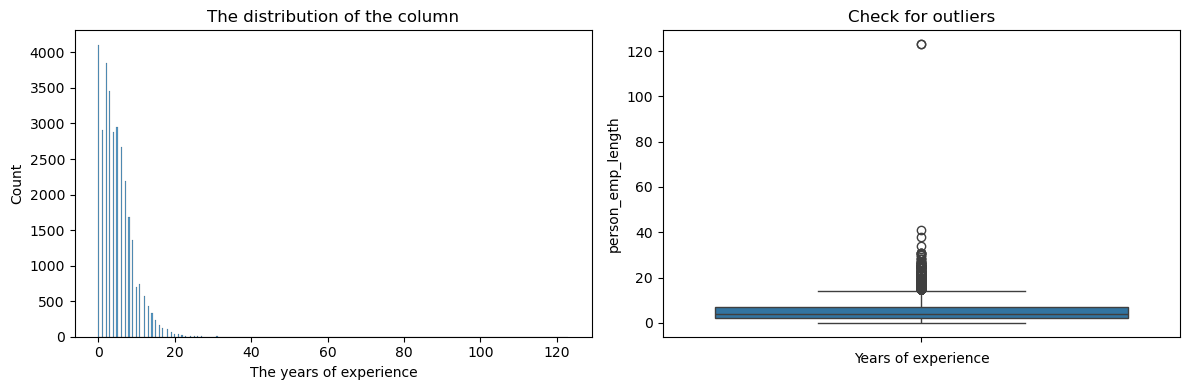

In [26]:
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
sns.histplot(data = df,x=df['person_emp_length'])
plt.xlabel('The years of experience')
plt.ylabel('Count')
plt.title("The distribution of the column")
plt.subplot(1, 2, 2)
sns.boxplot(df['person_emp_length'])
plt.xlabel('Years of experience')
plt.title('Check for outliers')
plt.tight_layout()
plt.show()

In [27]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
df['person_emp_length']=imputer.fit_transform(df[['person_emp_length']])
df['loan_int_rate']=imputer.fit_transform(df[['loan_int_rate']])

In [28]:
df['person_emp_length'].isna().sum()
df['loan_int_rate'].isna().sum()

np.int64(0)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


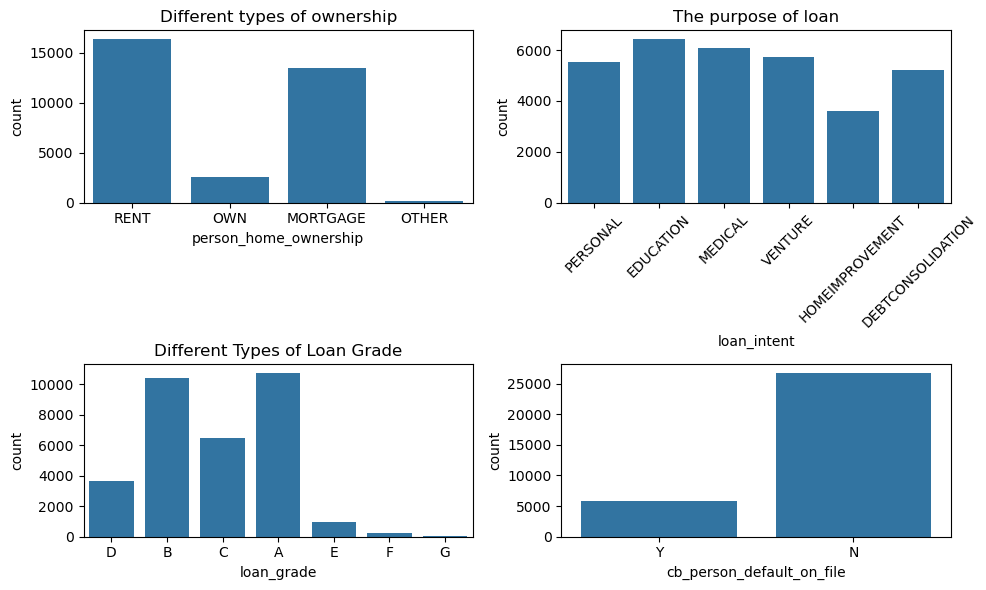

In [30]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
sns.countplot(x='person_home_ownership',data=df)
plt.title("Different types of ownership")
plt.subplot(2,2,2)
sns.countplot(x='loan_intent',data=df)
plt.title('The purpose of loan')
plt.xticks(rotation=45)
plt.subplot(2,2,3)
sns.countplot(x='loan_grade',data=df)
plt.title('Different Types of Loan Grade')
plt.subplot(2,2,4)
sns.countplot(x='cb_person_default_on_file',data=df)
plt.tight_layout()
plt.show()  

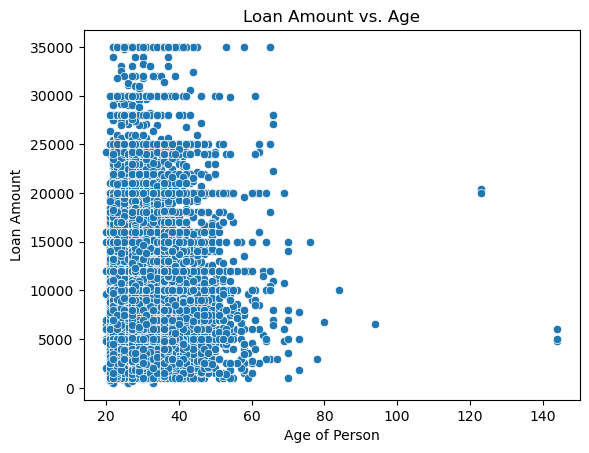

In [31]:
#Bivariate Analysis
sns.scatterplot(x='person_age', y='loan_amnt', data=df)
plt.title('Loan Amount vs. Age')
plt.xlabel('Age of Person')
plt.ylabel('Loan Amount')
plt.show()

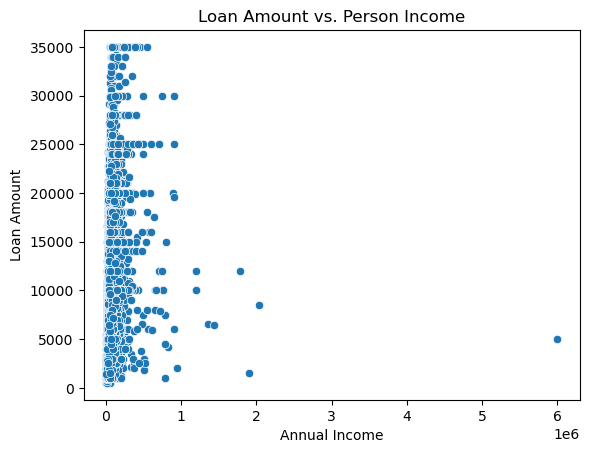

In [32]:
sns.scatterplot(x='person_income', y='loan_amnt', data=df)
plt.title('Loan Amount vs. Person Income')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.show()

In [33]:
#numerical vs categorical

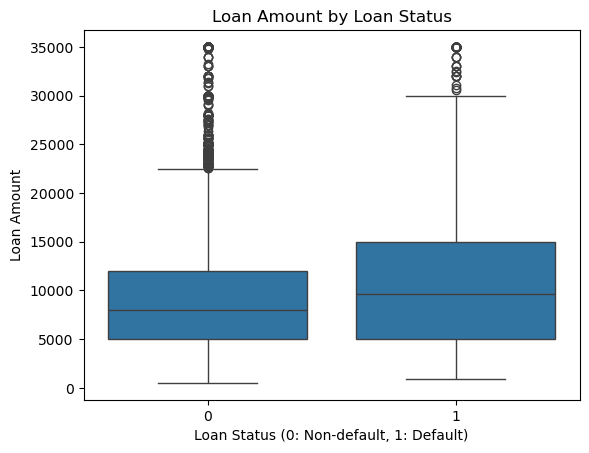

In [34]:
sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.title('Loan Amount by Loan Status')
plt.xlabel('Loan Status (0: Non-default, 1: Default)')
plt.ylabel('Loan Amount')
plt.show()

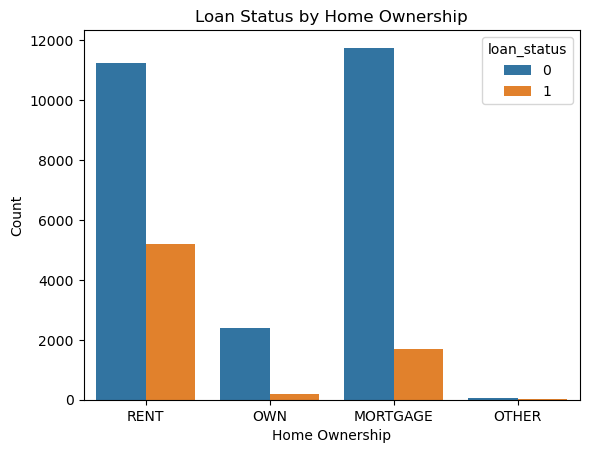

In [35]:
sns.countplot(x='person_home_ownership', hue='loan_status', data=df)
plt.title('Loan Status by Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Count')
plt.show()

In [36]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
ohe =  OneHotEncoder(sparse_output=False)
df_ohe = pd.DataFrame(ohe.fit_transform(df[['person_home_ownership','loan_intent','loan_grade']]),columns= ohe.get_feature_names_out())

In [37]:
Lab_en = LabelEncoder()

In [38]:
df_cb = pd.DataFrame(Lab_en.fit_transform(df['cb_person_default_on_file']),columns = ['cb_person_default_on_file'])

In [39]:
numerical = df.drop(columns=['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file'])
numerical

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
0,22,59000,123.0,35000,16.02,1,0.59,3
1,21,9600,5.0,1000,11.14,0,0.10,2
2,25,9600,1.0,5500,12.87,1,0.57,3
3,23,65500,4.0,35000,15.23,1,0.53,2
4,24,54400,8.0,35000,14.27,1,0.55,4
...,...,...,...,...,...,...,...,...
32576,57,53000,1.0,5800,13.16,0,0.11,30
32577,54,120000,4.0,17625,7.49,0,0.15,19
32578,65,76000,3.0,35000,10.99,1,0.46,28
32579,56,150000,5.0,15000,11.48,0,0.10,26


In [40]:
df_ = pd.concat([numerical,df_ohe,df_cb],axis=1)

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_)

In [42]:
scaled_data

array([[1.61290323e-02, 9.17278185e-03, 1.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
       [8.06451613e-03, 9.33955971e-04, 4.06504065e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.03225806e-02, 9.33955971e-04, 8.13008130e-03, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [3.62903226e-01, 1.20080053e-02, 2.43902439e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.90322581e-01, 2.43495664e-02, 4.06504065e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.70967742e-01, 6.33755837e-03, 1.62601626e-02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [43]:
X = scaled_data.drop(columns=['loan_status'])
y = scaled_data['loan_status']

AttributeError: 'numpy.ndarray' object has no attribute 'drop'

In [44]:
scaled_data = pd.DataFrame(scaled_data, columns=df_.columns)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [ ]:
X_train.shape, y_train.shape

In [ ]:
X_test.shape , y_test.shape

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

In [ ]:
y_pred = knn.predict(X_test)
y_pred

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_pred,y_test))

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score


X = scaled_data.drop(columns=['loan_status'])
y = scaled_data['loan_status']


In [ ]:
numerical_features = ['person_age', 'person_income','person_emp_length', 'loan_amnt', 'loan_int_rate','loan_percent_income','cb_person_cred_hist_length']
categorical_features = ['cb_person_default_on_file']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', GaussianNB(), numerical_features),
        ('cat', CategoricalNB(), categorical_features)
    ]
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

gnb = GaussianNB()
cnb = CategoricalNB()


X_train_cat = X_train[categorical_features]
X_train_num = X_train[numerical_features]
X_test_cat = X_test[categorical_features]
X_test_num = X_test[numerical_features]

gnb.fit(X_train_num, y_train)
cnb.fit(X_train_cat, y_train)

log_proba_num_test = gnb.predict_log_proba(X_test_num)
log_proba_cat_test = cnb.predict_log_proba(X_test_cat)

class_priors = y_train.value_counts(normalize=True)
log_prior = [np.log(class_priors[0]), np.log(class_priors[1])]

total_log_proba = log_proba_num_test + log_proba_cat_test - log_prior

# Get the final predictions by finding the class with the maximum total probability
y_pred = np.argmax(total_log_proba, axis=1)

# Evaluate the model
print(classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))